# TODO

- [ ] size ratio vs concentration
- [ ] examples of different morphologies for presentation
- [ ] Gini - M20 colored by halpha filling factor

# Import and Read Tables

In [1]:
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.table import Table
homedir = os.getenv("HOME")
sys.path.append(os.path.join(homedir,'github/hapy/scripts/'))

import warnings
warnings.filterwarnings("ignore")

from hapy.utils.results_table import prepare_analysis_table

In [2]:
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260330/merged_results.fits'

infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260502.fits'
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260507/merged_results_virgo_20260507.fits'
tab = Table.read(infile)



cinfile = '/Users/rfinn/research/Virgo/koopmann-images/hapy_results/cluster/hapy-output-20260430/merged_results_archive_20260430.fits'
cinfile = '/Users/rfinn/research/Virgo/koopmann-images/hapy_results/cluster/hapy-output-20260507/merged_results_archive_20260507.fits'
ctab = Table.read(infile)

%run ~/github/Virgo/programs/readtablesv2.py

%run ~/github/hapy/scripts/science_morphology.py $infile --scheme virgo --ctable $cinfile

#%run ~/github/hapy/scripts/science_morphology.py $infile --scheme virgo 

table directory =  /Users/rfinn/research/Virgo/tables-north/v2/
Read 784 rows from /Users/rfinn/research/Virgo/hatools_test/hapy-output-20260507/merged_results_virgo_20260507.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 68, 'low': 283, 'medium': 433}
ELL_MISMATCH 235
FILTER_WARNING 76
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 278

Reading cluster table

UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 17, 'low': 7, 'medium': 34}
ELL_MISMATCH 19
FILTER_WARNING 0
WARN_MASK 2
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 2


# Define VFS Quantities

In [3]:
ssfr = v.cigale['bayes.sfh.sfr'] / v.cigale['bayes.stellar.m_star']

logsfr = np.log10(v.cigale['bayes.sfh.sfr'])
logmstar = np.log10(v.cigale['bayes.stellar.m_star'])
logssfr = logsfr - logmstar


# Kim's fit to the star-forming main sequence
m = 0.7988122
b = -8.5557
logsfr_ms = m * logmstar + b

delta_logsfr = logsfr - logsfr_ms


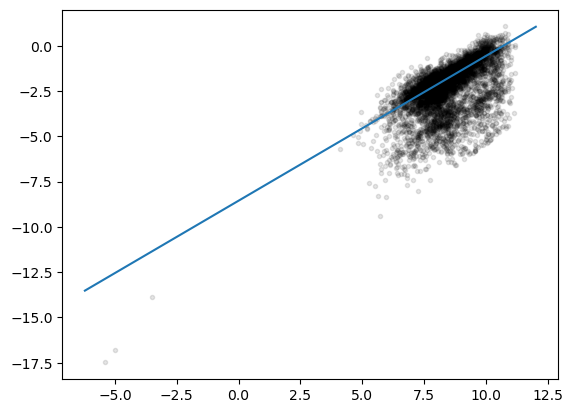

In [4]:
plt.plot(logmstar, logsfr,'k.',alpha=.1)

x1,x2 = plt.xlim()
xline = np.linspace(x1,x2,100)
yline = m * xline + b
plt.plot(xline,yline)

# Define HAPY Sample

In [5]:
def get_sci_flag(tab):
    sel = (
        #(tab['QC_TIER'] <= 'D') &                     # A or B only
        (tab['CLEAN']) &                # exclude CAUTION/TBD
        (tab['MASK_OK']) &
        (tab['PHOT_OK']) &
        (tab['R_PROFILE_OK']) &
        (tab['H_PROFILE_OK']) &
        (tab['ELLIP_SMA_PIX'] > 5) &                  # avoid tiny objects
        np.isfinite(tab['R50_ARCSEC']) &
        np.isfinite(tab['H50_ARCSEC']) & 
        (tab['H_HAPY_SNP_DET'] > 5) & 
        (tab["logmstar"] > 7)
    )
    return sel
tabs = [tab, ctab, trunctab]

for i in range(len(tabs)):
    vfindex = tabs[i]["VFINDEX"]
    tabs[i]["logmstar"] = logmstar[tabs[i]["VFINDEX"]]
    tabs[i]["logsfr"] = logsfr[tabs[i]["VFINDEX"]]
    tabs[i]["logssfr"] = logssfr[tabs[i]["VFINDEX"]]
    tabs[i]["delta_logsfr"] = delta_logsfr[tabs[i]["VFINDEX"]]
    tabs[i]["filament_member"] = v.env["filament_member"][vfindex]
    tabs[i]["poor_group_memb"] = v.env["poor_group_memb"][vfindex]
    tabs[i]["rich_group_memb"] = v.env["rich_group_memb"][vfindex]
    tabs[i]["pure_field"] = v.env["pure_field"][vfindex]
    tabs[i]["cluster_member"] = v.env["cluster_member"][vfindex]


for t in tabs:
    print(np.sum(get_sci_flag(t)),len(t))
stab = tab[get_sci_flag(tab)]
sctab = ctab[get_sci_flag(ctab)]
strunctab = trunctab[get_sci_flag(trunctab)]

tabs = [stab, sctab, strunctab]



432 784
42 58
4 4


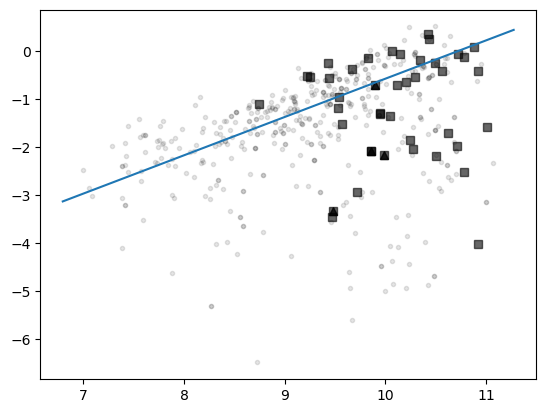

In [6]:
tabs = [stab, sctab, strunctab]

shapes = ['.','s','^']
alphas = [.1,.6, .8]
for i in range(len(tabs)):
    t = tabs[i]
    plt.plot(t['logmstar'], t['logsfr'],'k.',marker=shapes[i],alpha=alphas[i])

x1,x2 = plt.xlim()
xline = np.linspace(x1,x2,100)
yline = m * xline + b
plt.plot(xline,yline)

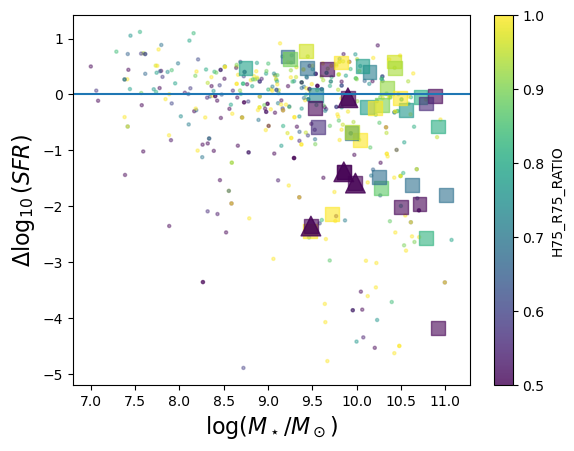

In [7]:
tabs = [stab, sctab, strunctab]

shapes = ['.','s','^']
alphas = [.4,.6, .8]
markersize=[20,100, 200]
v1 = 0.5
v2 = 1.
xname = 'logmstar'
yname = 'delta_logsfr'
cname = 'H75_R75_RATIO'
for i in range(len(tabs)):
    t = tabs[i]
    plt.scatter(t[xname], t[yname],c=t[cname],s=markersize[i],marker=shapes[i],alpha=alphas[i],vmin=v1,vmax=v2)

plt.axhline()

plt.ylabel("$\Delta \log_{10}(SFR)$",fontsize=16)
plt.xlabel("$\log(M_\star/M_\odot) $",fontsize=16)
plt.colorbar(label=cname)

(0.0, 2.0)

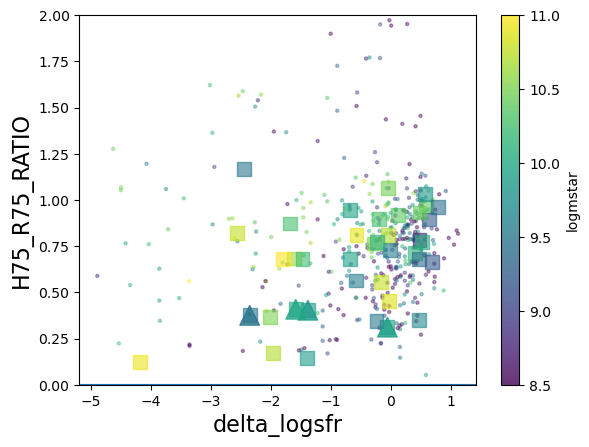

In [8]:
tabs = [stab, sctab, strunctab]

shapes = ['.','s','^']
alphas = [.4,.6, .8]
markersize=[20,100, 200]
v1 = 8.5
v2 = 11.
cname = 'logmstar'
xname = 'delta_logsfr'
yname = 'H75_R75_RATIO'
for i in range(len(tabs)):
    t = tabs[i]
    plt.scatter(t[xname], t[yname],c=t[cname],s=markersize[i],marker=shapes[i],alpha=alphas[i],vmin=v1,vmax=v2)

plt.axhline()
plt.ylabel(yname,fontsize=16)
plt.xlabel(xname,fontsize=16)
plt.colorbar(label=cname)
plt.ylim(0,2)

# Size Comparison

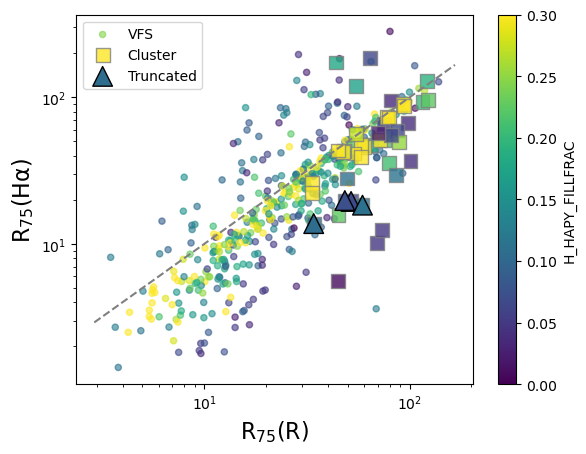

In [56]:

xname = 'R75_ARCSEC'
xlabel=r"$\rm R_{75} (R)$"

yname = 'H75_ARCSEC'
ylabel=r"$\rm R_{75} (H\alpha)$"

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H_HAPY_SNP_DET'
v1=3
v2=15
#clabel = 'Halpha SNR/pixel'

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=.3

clabel  = cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']

clabel=cname
plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,edgecolors='0.5',marker='s',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
plt.gca().set_yscale("log")
plt.gca().set_xscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


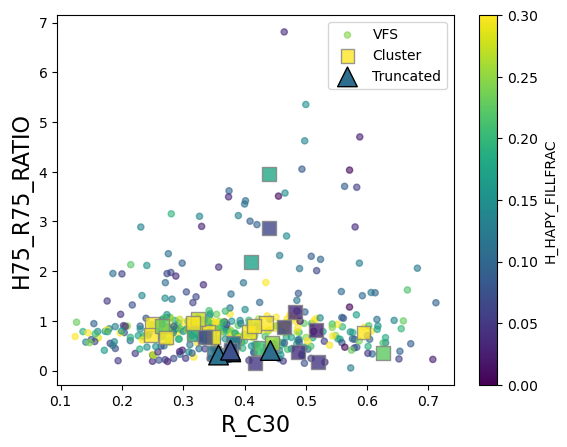

In [58]:

xname = 'R_C30'
#xlabel=r"$\rm R_{75} (R)$"
xlabel = xname

yname = 'H75_R75_RATIO'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel = yname

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=.3

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

#cname = 'H_HAPY_SNP_DET'
#v1=3
#v2=15
#clabel = 'Halpha SNR/pixel'


#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']

clabel=cname
plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,edgecolors='0.5',marker='s',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()
plt.ylabel(ylabel,fontsize=16)

#plt.gca().set_yscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)

#plt.axis([0,.8,0,5])

#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


(-0.2, 1.5)

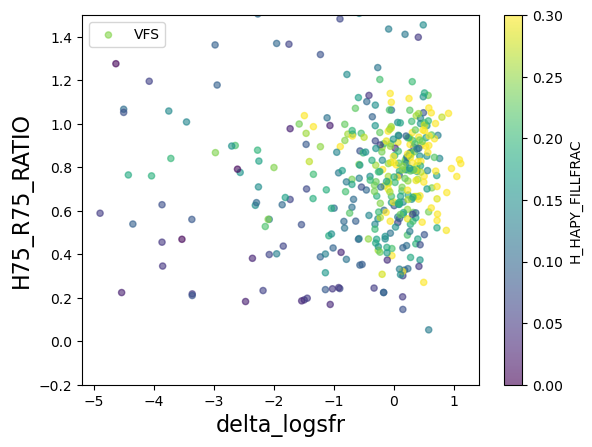

In [168]:

xname = 'delta_logsfr'
#xlabel=r"$\rm R_{75} (R)$"
xlabel = xname

yname = 'H75_R75_RATIO'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel = yname

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=.3

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

#cname = 'H_HAPY_SNP_DET'
#v1=3
#v2=15
#clabel = 'Halpha SNR/pixel'


#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']

clabel=cname
plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
#sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,edgecolors='0.5',marker='s',label='Cluster')

#sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()
plt.ylabel(ylabel,fontsize=16)

#plt.gca().set_yscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)

#plt.axis([0,.8,0,5])

#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')
plt.ylim(-.2,1.5)


# HAPY Morphology 1:1 Plots

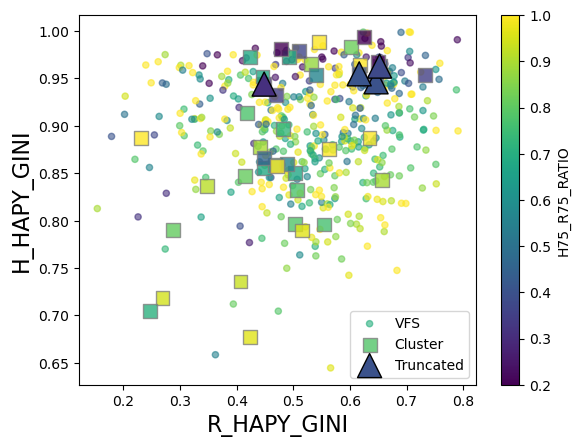

In [68]:

xname = 'R_HAPY_GINI'
xlabel=r"$\rm R_{75} (R)$"
xlabel=xname

yname = 'H_HAPY_GINI'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel=yname

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


#cname = 'H_HAPY_FILLFRAC'
#v1=0.
#v2=.3

clabel=cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1+.2, x2, 100)
#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


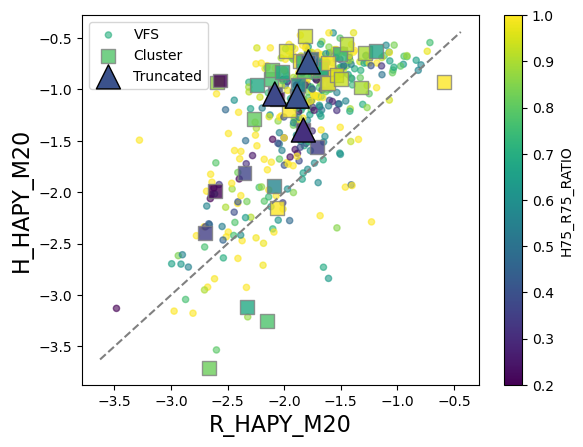

In [69]:

xname = 'R_HAPY_M20'
xlabel=r"$\rm R_{75} (R)$"
xlabel=xname

yname = 'H_HAPY_M20'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel=yname

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


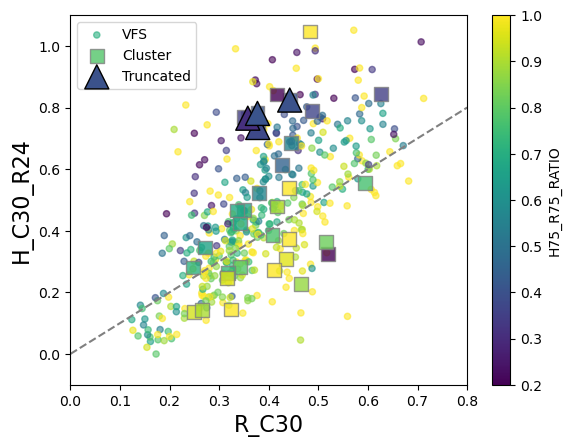

In [70]:

xname = 'R_C30'
xlabel=xname

yname = 'H_C30_R24'
ylabel=yname

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")

plt.axis([0,.8,-.1,1.1])

# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


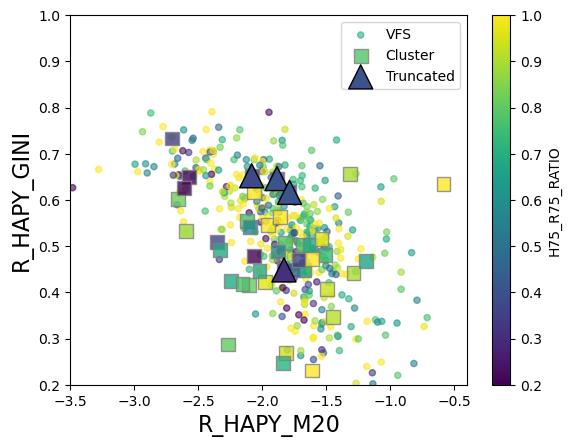

In [156]:

xname = 'R_HAPY_M20'
xlabel=xname

yname = 'R_HAPY_GINI'
ylabel=yname

cname = 'R_C30'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")

plt.axis([-3.5,-.4,.2,1.])

# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


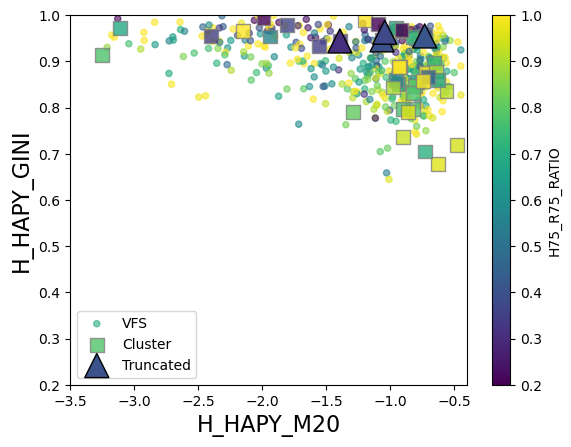

In [157]:

xname = 'H_HAPY_M20'
xlabel=xname

yname = 'H_HAPY_GINI'
ylabel=yname

cname = 'R_C30'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")

#plt.axis([0,.8,-.1,1.1])
plt.axis([-3.5,-.4,.2,1.])
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


# STATMORPH Metrics

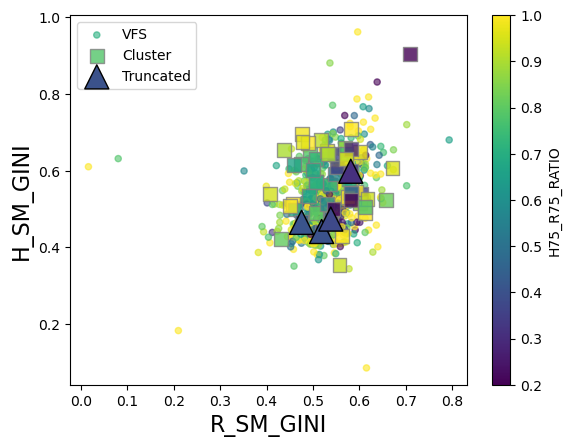

In [10]:

xname = 'R_SM_GINI'
xlabel=r"$\rm R_{75} (R)$"
xlabel=xname

yname = 'H_SM_GINI'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel=yname

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
#plt.plot(xline,xline,'k--',color='0.5')
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')


# Test Plot

Saved plots/gini_m20_vectors_hapy.png
N plotted = 150


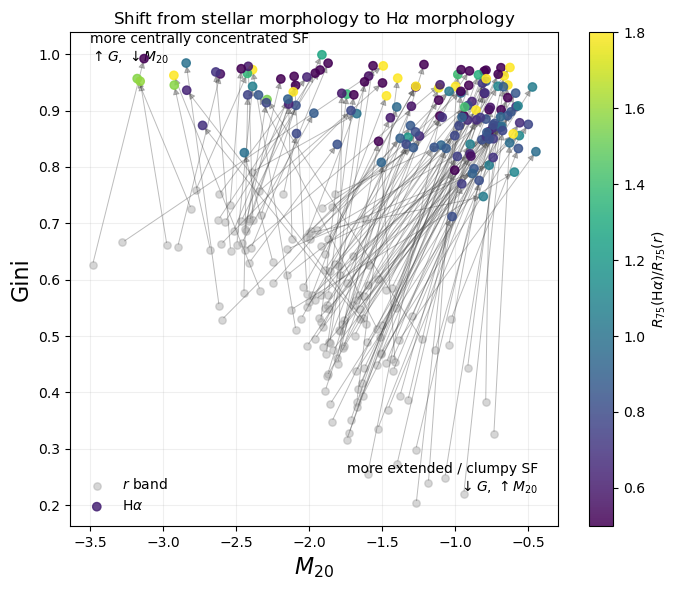

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.table import Table


def plot_gini_m20_vectors(
    tab,
    outdir="plots",
    outfile="gini_m20_vectors_hapy.png",
    use_qc_tiers=("A", "B"),
    max_arrows=None,
):
    """
    Plot r-band and Halpha morphology in Gini-M20 space, with vectors
    from r-band -> Halpha for each galaxy.
    """

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Columns
    # ------------------------------------------------------------
    r_gini = np.array(tab["R_HAPY_GINI"], dtype=float)
    h_gini = np.array(tab["H_HAPY_GINI"], dtype=float)

    r_m20 = np.array(tab["R_HAPY_M20"], dtype=float)
    h_m20 = np.array(tab["H_HAPY_M20"], dtype=float)

    # Optional color quantity: Halpha-to-r size ratio
 
    size_ratio = tab["H75_R75_RATIO"]



    idx = np.arange(len(tab))

    if max_arrows is not None and len(idx) > max_arrows:
        rng = np.random.default_rng(123)
        idx = rng.choice(idx, size=max_arrows, replace=False)

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    # r-band points
    ax.scatter(
        r_m20[idx],
        r_gini[idx],
        s=28,
        alpha=0.45,
        color="0.65",
        label=r"$r$ band",
        zorder=2,
    )

    # Halpha points
    if size_ratio is not None:
        sc = ax.scatter(
            h_m20[idx],
            h_gini[idx],
            s=36,
            c=size_ratio[idx],
            vmin=0.5,
            vmax=1.8,
            alpha=0.85,
            label=r"H$\alpha$",
            zorder=4,
        )
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label(r"$R_{75}({\rm H}\alpha) / R_{75}(r)$")
    else:
        ax.scatter(
            h_m20[idx],
            h_gini[idx],
            s=36,
            alpha=0.85,
            label=r"H$\alpha$",
            zorder=4,
        )

    # vectors: r -> Halpha
    for i in idx:
        ax.annotate(
            "",
            xy=(h_m20[i], h_gini[i]),
            xytext=(r_m20[i], r_gini[i]),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=0.7,
                alpha=0.35,
                color="0.25",
                shrinkA=2,
                shrinkB=2,
            ),
            zorder=3,
        )

    # ------------------------------------------------------------
    # Labels / guide text
    # ------------------------------------------------------------
    ax.set_xlabel(r"$M_{20}$",fontsize=16)
    ax.set_ylabel("Gini",fontsize=16)
    ax.set_title(r"Shift from stellar morphology to H$\alpha$ morphology")

    ax.text(
        0.04,
        1.0,
        r"more centrally concentrated SF" + "\n" + r"$\uparrow G$, $\downarrow M_{20}$",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
    )

    ax.text(
        0.96,
        0.06,
        r"more extended / clumpy SF" + "\n" + r"$\downarrow G$, $\uparrow M_{20}$",
        transform=ax.transAxes,
        va="bottom",
        ha="right",
        fontsize=10,
    )

    # Typical useful limits; adjust after first look
    #ax.set_xlim(-2.8, -0.5)
    #ax.set_ylim(0.25, 0.9)

    ax.legend(frameon=False, loc="lower left")
    ax.grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(outdir / outfile, dpi=200)
    #plt.close(fig)

    print(f"Saved {outdir / outfile}")
    print(f"N plotted = {len(idx)}")



plot_gini_m20_vectors(stab, outdir="plots", max_arrows=150)
plt.show()

# Delta Gini, Delta M20, colored by filling factor

In [11]:
%run ~/github/hapy/scripts/science_morphology.py $infile --scheme virgo --ctable $cinfile

Read 784 rows from /Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260502.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 95, 'low': 283, 'medium': 406}
ELL_MISMATCH 235
FILTER_WARNING 76
WARN_MASK 11
BRIGHT_STAR_FLAG 4
WARN_WEAK_HA 278

Reading cluster table

UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 17, 'low': 7, 'medium': 34}
ELL_MISMATCH 19
FILTER_WARNING 0
WARN_MASK 2
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 2


In [12]:
for c in tab.colnames:
    if 'VF' in c:
        print(c)
#tab['VFINDEX']

VFID
VFINDEX


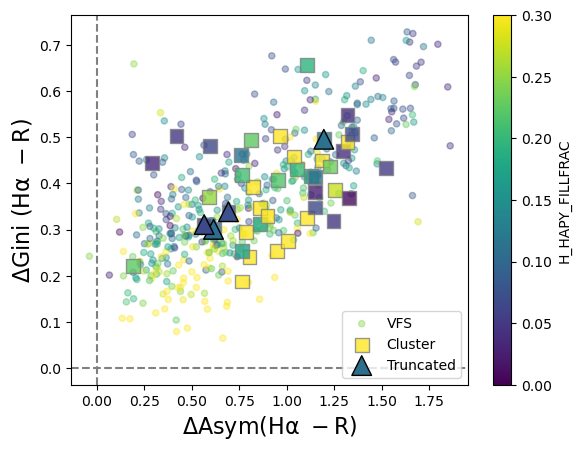

In [158]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"
xname = 'DELTA_ASYM'
xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"
yname = 'DELTA_GINI'

c = tab['H_HAPY_FILLFRAC']
c = tab['H_HAPY_SNP_DET']
cc = ctab['H_HAPY_SNP_DET']

cname = 'H_HAPY_SNP_DET'
v1=3
v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=.3

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]


#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']
#clabel = 'Halpha SNR/pixel'
clabel = cname
plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.4,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(r"$\rm \Delta Gini \ (H\alpha \ - R)$",fontsize=16)
plt.axhline(ls='--',color='0.5')
plt.axvline(ls='--',color='0.5')

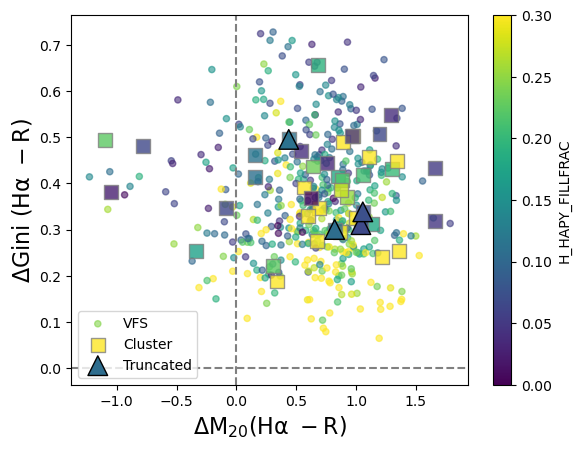

In [159]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"
#xname = 'DELTA_ASYM'
#xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

yname = 'DELTA_GINI'
ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"



# cname = 'H_HAPY_SNP_DET'
# clabel = 'Halpha SNR/pixel'
# v1=3
# v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=.3





clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

ax = plt.gca()
# ax.text(
#     0.02,
#     .96,
#     r"more centrally concentrated SF" + "\n" + r"$\uparrow G$, $\downarrow M_{20}$",
#     transform=ax.transAxes,
#     va="top",
#     ha="left",
#     fontsize=10,
# )

# ax.text(
#     .96,
#     0.02,
#     r"more extended / clumpy SF" + "\n" + r"$\downarrow G$, $\uparrow M_{20}$",
#     transform=ax.transAxes,
#     va="bottom",
#     ha="right",
#     fontsize=10,
# )

#plt.axis([-2,2,-.1,.95])
plt.xlabel(xlabel,fontsize=16)
plt.legend(loc="lower left")

plt.ylabel(ylabel,fontsize=16)
plt.axhline(ls='--',color='0.5')
plt.axvline(ls='--',color='0.5')

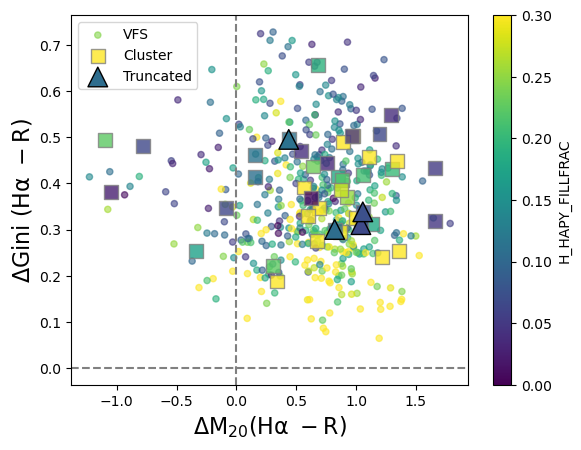

In [160]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"
#xname = 'DELTA_ASYM'
#xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

yname = 'DELTA_GINI'
ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"



cname = 'H_HAPY_SNP_DET'
clabel = 'Halpha SNR/pixel'
v1=5
v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=0.3

clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
plt.axhline(ls='--',color='0.5')
plt.axvline(ls='--',color='0.5')

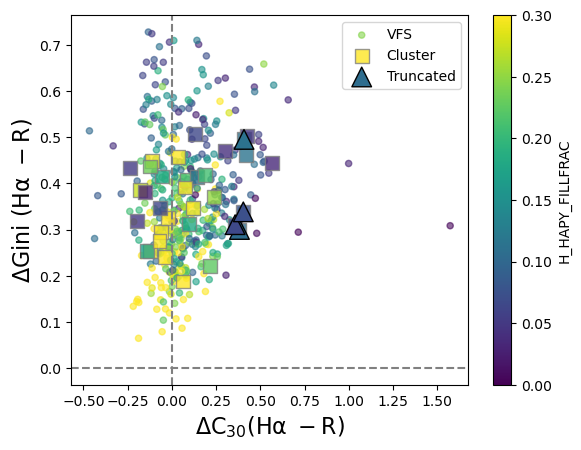

In [201]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"

xname = 'DELTA_C30'
xlabel=r"$\rm \Delta C_{30} (H\alpha \ - R)$"
#xname = 'DELTA_ASYM'
#xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

yname = 'DELTA_GINI'
ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"



cname = 'H_HAPY_SNP_DET'
clabel = 'Halpha SNR/pixel'
v1=5
v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=0.3

clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
plt.axhline(ls='--',color='0.5')
plt.axvline(ls='--',color='0.5')

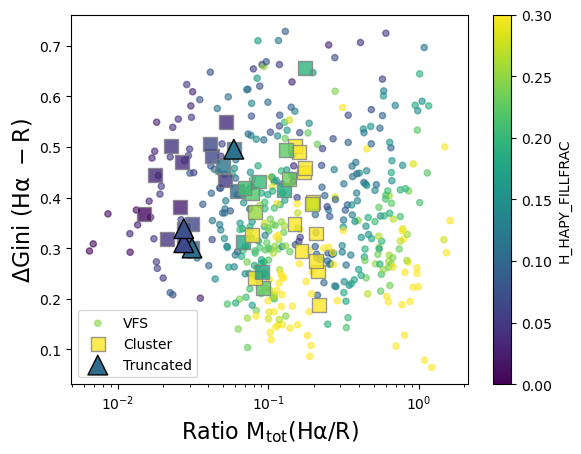

In [9]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"

xname = 'DELTA_C30'
xlabel=r"$\rm \Delta C_{30} (H\alpha \ - R)$"

xname = 'RATIO_HAPY_MTOT'
xlabel=r"$\rm Ratio \ M_{tot} (H\alpha / R)$"

#xname = 'DELTA_ASYM'
#xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

yname = 'DELTA_GINI'
ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"



cname = 'H_HAPY_SNP_DET'
clabel = 'Halpha SNR/pixel'
v1=5
v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=0.3

clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')

plt.gca().set_xscale("log")

Text(0, 0.5, '$\\rm \\Delta Gini \\ (H\\alpha \\ - R)$')

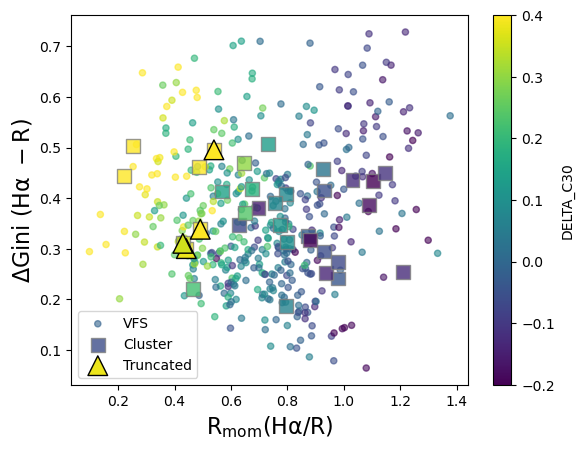

In [14]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"

xname = 'DELTA_C30'
xlabel=r"$\rm \Delta C_{30} (H\alpha \ - R)$"

xname = 'HAPY_RMOM_RATIO'
xlabel=r"$\rm R_{mom} (H\alpha / R)$"

#xname = 'RATIO_HAPY_MTOT'
#xlabel=r"$\rm M_{TOT} (H\alpha / R)$"

#xname = 'DELTA_ASYM'
#xlabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

yname = 'DELTA_GINI'
ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"



cname = 'H_HAPY_SNP_DET'
clabel = 'Halpha SNR/pixel'
v1=5
v2=20

cname = 'H_HAPY_FILLFRAC'
v1=0
v2=0.3

cname = 'DELTA_C30'
v1=-.2
v2=.4

clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')

#plt.gca().set_xscale("log")

Text(0, 0.5, 'H_HAPY_FILLFRAC')

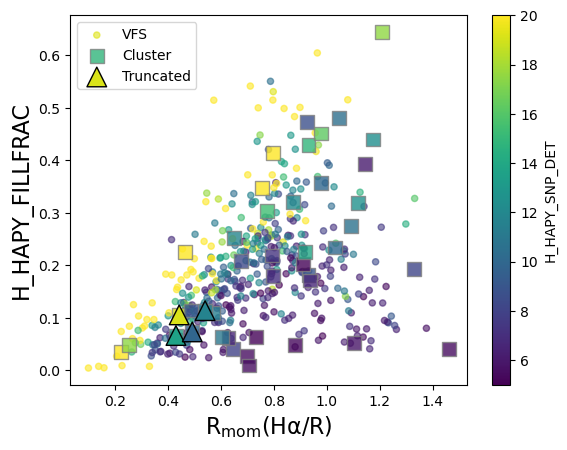

In [22]:
xname = 'DELTA_M20'
xlabel=r"$\rm \Delta M_{20} (H\alpha \ - R)$"

xname = 'DELTA_C30'
xlabel=r"$\rm \Delta C_{30} (H\alpha \ - R)$"

xname = 'HAPY_RMOM_RATIO'
xlabel=r"$\rm R_{mom} (H\alpha / R)$"


#xname = 'RATIO_HAPY_MTOT'
#xlabel=r"$\rm M_{TOT} (H\alpha / R)$"

yname = 'DELTA_ASYM'
ylabel=r"$\rm \Delta Asym (H\alpha \ - R)$"

#yname = 'DELTA_GINI'
#ylabel=r"$\rm \Delta Gini \ (H\alpha \ - R)$"

yname = "H75_R75_RATIO"
ylabel=r"$\rm  R_{75}(H\alpha)/R_{75}(r)$"

yname = 'H_HAPY_FILLFRAC'
ylabel = yname

cname = 'H_HAPY_SNP_DET'
clabel = 'Halpha SNR/pixel'
v1=5
v2=20

#cname = 'H_HAPY_FILLFRAC'
#v1=0
#v2=0.3

#cname = 'DELTA_GINI'
#v1=.2
#v2=0.5

#cname = 'DELTA_C30'
#v1=-.2
#v2=.4

clabel = cname


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=200,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.axhline(ls='--',color='0.5')
#plt.axvline(ls='--',color='0.5')

#plt.gca().set_yscale("log")

# Delta HAPY Gini vs Delta STAMORPH Gini 

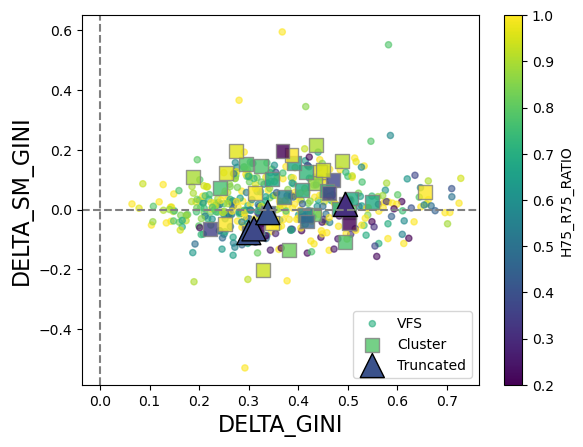

In [45]:

xname = 'DELTA_GINI'
xlabel=r"$\rm R_{75} (R)$"
xlabel=xname

yname = 'DELTA_SM_GINI'
ylabel=r"$\rm R_{75} (H\alpha)$"
ylabel=yname

cname = 'H_HAPY_M20'
v1=-2
v2=-.5

#c = ssfr[tab['VFINDEX']]
#cc = ssfr[ctab['VFINDEX']]

cname = 'H75_R75_RATIO'
v1=0.2
v2=1.

clabel=cname

#v1=1e-11
#v2=.5e-10
#c = tab['QC_TIER']


plt.figure()
sc = plt.scatter(stab[xname],stab[yname],c=stab[cname],alpha=.6,vmin=v1, vmax=v2,s=20,label='VFS')
sc = plt.scatter(sctab[xname],sctab[yname],c=sctab[cname],alpha=.8,vmin=v1, vmax=v2,s=100,marker='s',edgecolors='0.5',label='Cluster')

sc = plt.scatter(strunctab[xname],strunctab[yname],c=strunctab[cname],alpha=1,vmin=v1, vmax=v2,s=300,marker='^',edgecolors='k',label="Truncated")

cb = plt.colorbar(label=clabel)

plt.xlabel(xlabel,fontsize=16)
plt.legend()

plt.ylabel(ylabel,fontsize=16)
#plt.gca().set_yscale("log")
#plt.gca().set_xscale("log")
# plot 1:1
x1, x2 = plt.xlim()
xline = np.linspace(x1, x2, 100)
#plt.plot(xline,xline,'k--',color='0.5')
plt.axhline(ls='--',color='0.5')
plt.axvline(ls='--',color='0.5')


# Sample Properties

## SFR - Stellar mass

(6.5, 11.2, -6.0, 1.0)

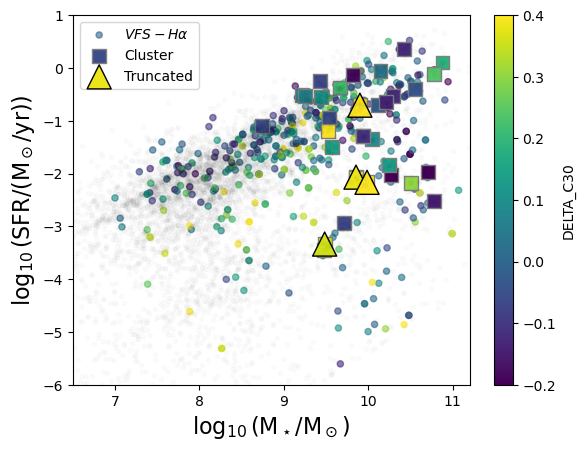

In [85]:
mstar_flag = logmstar > 6.5
tabs = [stab, sctab, strunctab]

alphas = [.6,1,1]
ss = [20, 100, 300]
markers = ['o','s','^']
edges = [None,'0.5','k']
labels = [r"$VFS-H\alpha$", 'Cluster','Truncated']

v1=2
v2=15
cname = 'H_HAPY_SNP_DET'

v1=0
v2=.3
cname = 'H_HAPY_FILLFRAC'

v1=0.8
v2=1
cname = 'H_HAPY_GINI'

v1=0.
v2=.6
cname = 'H_C30_R24'


v1=-.2
v2=.4
cname = 'DELTA_C30'

v1=-.2
v2=.4
cname = 'DELTA_GINI'

plt.figure()

plt.plot(logmstar[mstar_flag], logsfr[mstar_flag],'k.',alpha=.015)
x = logmstar
y = logsfr
for i in range(len(tabs)):
    pidx = tabs[i]['VFINDEX']
    plt.scatter(x[pidx],y[pidx],c=tabs[i][cname],alpha=alphas[i],s=ss[i],marker=markers[i],edgecolors=edges[i],label=labels[i],vmin=v1,vmax=v2)

plt.xlabel(r"$ \rm \log_{10}(M_\star/M_\odot)$", fontsize=16)

plt.ylabel(r"$ \rm \log_{10}(SFR/(M_\odot/yr))$", fontsize=16)
plt.colorbar(label=cname)
plt.legend()

plt.axis([6.5,11.2,-6,1])

## Groups

In [132]:
envs = ["pure_field","poor_group_memb","rich_group_memb","filament_member"]#,"cluster_member"]

<Figure size 640x480 with 0 Axes>

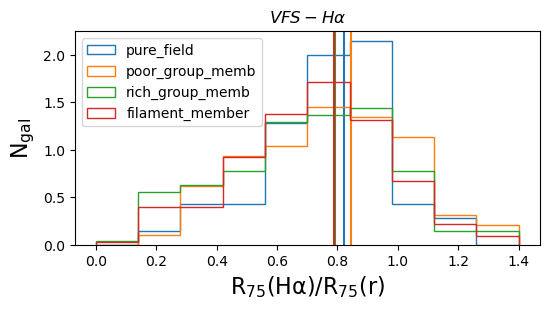

In [141]:
plt.figure()

mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']

mstar_flag = logmstar > 6.5
tabs = [stab]#, sctab]#, strunctab]

alphas = [.6,1,1]
ss = [20, 100, 300]
markers = ['o','s','^']
edges = [None,'0.5','k']
labels = [r"$VFS-H\alpha$", 'Cluster','Truncated']

v1=2
v2=15
cname = 'H_HAPY_SNP_DET'

v1=0
v2=.3
cname = 'H_HAPY_FILLFRAC'

v1=0.8
v2=1
cname = 'H_HAPY_GINI'

v1=0.
v2=.6
cname = 'H_C30_R24'


v1=-.2
v2=.4
cname = 'DELTA_C30'

v1=-.2
v2=.4
cname = 'DELTA_GINI'

plt.figure(figsize = (6,10))
plt.subplots_adjust(hspace=.3)
mybins = np.linspace(0,1.4,11)
for i in range(len(tabs)):
    plt.subplot(3,1,i+1)
    t = tabs[i]
    for j in range(len(envs)):
        e = envs[j]
        
        #print(e,t[e])
        flag = tabs[i][e]
        #print(np.sum(flag))
        #print(flag)
        plt.hist(tabs[i]["H75_R75_RATIO"][flag],bins=mybins,label=str(e),alpha=1,histtype='step',density=True)
        plt.axvline(np.median(tabs[i]["H75_R75_RATIO"][flag]),color=mycolors[j])
    plt.title(labels[i])
plt.xlabel(r"$ \rm R_{75}(H\alpha)/R_{75}(r)$", fontsize=16)

plt.ylabel(r"$ \rm N_{gal}$", fontsize=16)
#plt.colorbar(label=cname)

plt.legend()
#plt.axis([6.5,11.2,-6,1])





(0.0, 1.5)

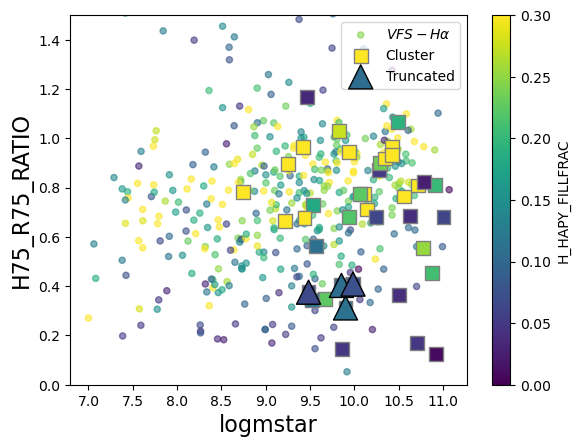

In [151]:
# distribution of B/A


tabs = [stab, sctab, strunctab]

alphas = [.6,1,1]
ss = [20, 100, 300]
markers = ['o','s','^']
edges = [None,'0.5','k']
labels = [r"$VFS-H\alpha$", 'Cluster','Truncated']

v1=2
v2=15
cname = 'H_HAPY_SNP_DET'

v1=0
v2=.3
cname = 'H_HAPY_FILLFRAC'

#v1=0.8
#v2=1
#cname = 'H_HAPY_GINI'

#v1=0.
#v2=.6
#cname = 'H_C30_R24'


#v1=-.2
#v2=.4
#cname = 'DELTA_C30'

#v1=-.2
#v2=.4
#cname = 'DELTA_GINI'

plt.figure()


xname = "ELLIP_BA"
xname = "GAL_N"
xname = "logmstar"

yname = "H75_R75_RATIO"
for i in range(len(tabs)):
    pidx = tabs[i]['VFINDEX']
    plt.scatter(tabs[i][xname],tabs[i][yname],c=tabs[i][cname],alpha=alphas[i],s=ss[i],marker=markers[i],edgecolors=edges[i],label=labels[i],vmin=v1,vmax=v2)

plt.xlabel(xname, fontsize=16)

plt.ylabel(yname, fontsize=16)
plt.colorbar(label=cname)
plt.legend()

plt.ylim(0,1.5)
#plt.gca().set_yscale("log")
#plt.axis([6.5,11.2,-6,1])